# The Design Challenge

## Why is Electromagnetic Design So Hard?

The design of electromagnetic devices involves navigating a complex interplay of multiple factors that make optimization challenging:

### Design Parameters
- **Geometry**: Complex shapes with dozens of design parameters
- **Materials**: Nonlinear magnetic properties and saturation effects
- **Physics**: Maxwell's equations governing electromagnetic fields
- **Performance**: Multiple competing objectives (efficiency, torque, noise, cost)

### Traditional Design Limitations

Traditional design relies heavily on:
1. **Expert intuition** based on years of experience
2. **Computationally expensive simulations** (Finite Element Analysis)
3. **Limited design space exploration** due to time constraints

### The Computational Bottleneck

A single high-fidelity FEA simulation can take:
- **2D analysis**: 1-2 hours per motor geometry
- **3D multi-physics**: Days per simulation

This creates a fundamental bottleneck in design optimization.

In [1]:
# Let's visualize the design space challenge
import numpy as np
import matplotlib.pyplot as plt

# Design space dimensions for a typical IPM motor
design_params = [
    'Stator inner radius',
    'Stator outer radius', 
    'Rotor inner radius',
    'Rotor outer radius',
    'Air gap length',
    'Magnet dimensions',
    'Number of slots',
    'Tooth width',
    'Back iron thickness',
    'Magnet placement angle',
    'Winding turns',
    'Wire gauge'
]

print(f"Number of design parameters: {len(design_params)}")
print(f"Design space with just 10 samples per parameter: {10**len(design_params):.2e} possible designs")

Number of design parameters: 12
Design space with just 10 samples per parameter: 1.00e+12 possible designs


### Design Space Exploration Problem

Consider a typical Interior Permanent Magnet (IPM) motor with 12 design parameters:

- Exploring **100 samples per parameter** → 100^12 ≈ 10^24 possible designs
- Even sampling just **10,000 candidates** (a tiny fraction!) → **1-2 years of computation**

**Reality check**: Designers can typically only afford to simulate **50-100 designs** before committing to a prototype.

This means we explore less than **0.001% of the design space**. Optimal designs likely exist in the unexplored 99.999%.

In [2]:
# Calculate the exploration limitation
total_design_space = 10**12  # Conservative estimate
typical_simulations = 100
exploration_percentage = (typical_simulations / total_design_space) * 100

print(f"Total design space (conservative): {total_design_space:.2e} designs")
print(f"Typical number of FEA simulations: {typical_simulations}")
print(f"Design space explored: {exploration_percentage:.8f}%")
print(f"Unexplored design space: {100 - exploration_percentage:.8f}%")

# Time calculation
fea_time_hours = 2  # Conservative estimate for 2D FEA
total_time_years = (typical_simulations * fea_time_hours) / (24 * 365)
print(f"\nTime for {typical_simulations} FEA simulations: {total_time_years:.2f} years")

Total design space (conservative): 1.00e+12 designs
Typical number of FEA simulations: 100
Design space explored: 0.00000001%
Unexplored design space: 99.99999999%

Time for 100 FEA simulations: 0.02 years


## The V-Design Cycle

The **V-Design Cycle** (VDC) represents the standard product development process for electric machines:

### Design Phase (Descending Left Branch)
1. **System Requirements**: Specify performance targets (torque, efficiency, speed range)
2. **Conceptual Design**: Select machine topology and rough dimensions
3. **Detailed Design**: Optimize geometry using FEA simulations
4. **Performance Verification**: Multi-physics analysis (electromagnetic, thermal, structural)

### Manufacturing Phase (Ascending Right Branch)
5. **Prototype Fabrication**: Build physical prototype
6. **Experimental Testing**: Measure actual performance
7. **Validation**: Compare with design specifications

### The Problem: Iteration Overhead

When a design fails to meet requirements (which happens frequently), the process **restarts**. Each iteration through the V-cycle can take:

- **Simulation time**: Days to weeks for full multi-physics analysis
- **Prototyping time**: Weeks to months for physical fabrication
- **Testing time**: Weeks for comprehensive experimental validation

**Total time per iteration**: Months

For complex designs with tight specifications, multiple iterations are inevitable. The result? **Lengthy development cycles** and **limited design space exploration**.

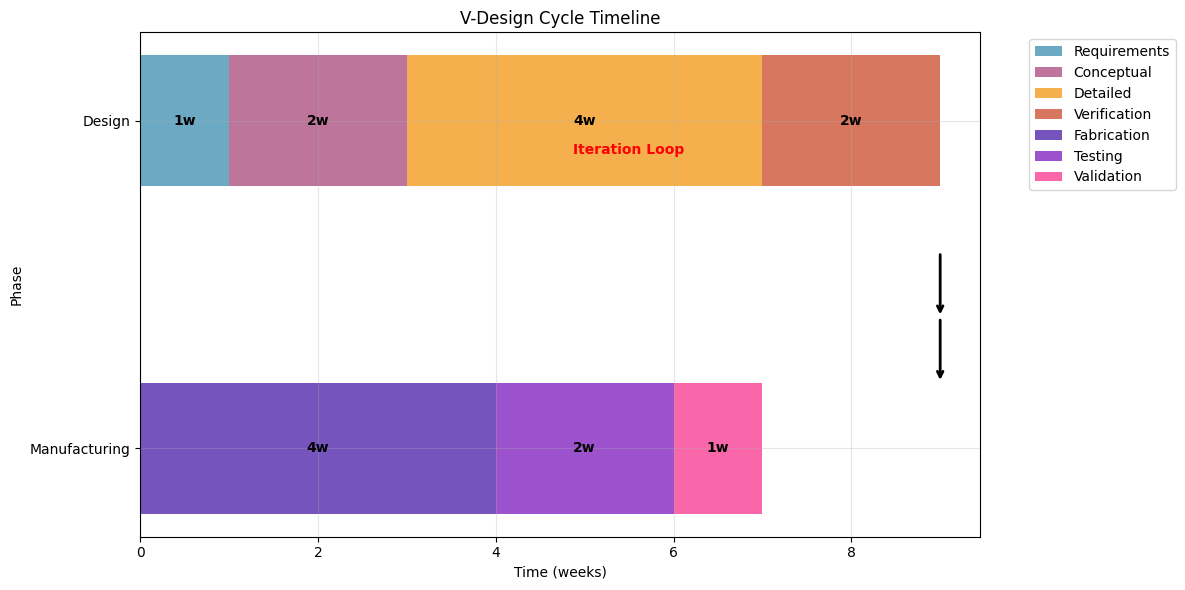

Total time per V-cycle iteration: 16 weeks (4.0 months)
With 3 iterations: 12.0 months
With 5 iterations: 20.0 months


In [3]:
# Visualize the V-Design Cycle timeline
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create timeline visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Design phase stages
design_stages = ['Requirements', 'Conceptual', 'Detailed', 'Verification']
design_times = [1, 2, 4, 2]  # weeks
manufacture_stages = ['Fabrication', 'Testing', 'Validation']
manufacture_times = [4, 2, 1]  # weeks

# Plot design phase
current_pos = 0
colors_design = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
for i, (stage, time, color) in enumerate(zip(design_stages, design_times, colors_design)):
    ax.barh(1, time, left=current_pos, height=0.4, color=color, alpha=0.7, label=stage)
    ax.text(current_pos + time/2, 1, f'{time}w', ha='center', va='center', fontweight='bold')
    current_pos += time

# Plot manufacturing phase  
current_pos = 0
colors_manufacture = ['#3A0CA3', '#7209B7', '#F72585']
for i, (stage, time, color) in enumerate(zip(manufacture_stages, manufacture_times, colors_manufacture)):
    ax.barh(0, time, left=current_pos, height=0.4, color=color, alpha=0.7, label=stage)
    ax.text(current_pos + time/2, 0, f'{time}w', ha='center', va='center', fontweight='bold')
    current_pos += time

# Add V-connection
ax.annotate('', xy=(9, 0.4), xytext=(9, 0.6),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.annotate('', xy=(9, 0.2), xytext=(9, 0.4),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Add iteration loop
ax.annotate('', xy=(10.5, 0.8), xytext=(0.5, 0.8),
            arrowprops=dict(arrowstyle='->', lw=2, color='red'))
ax.text(5.5, 0.9, 'Iteration Loop', ha='center', color='red', fontweight='bold')

ax.set_xlabel('Time (weeks)')
ax.set_ylabel('Phase')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Manufacturing', 'Design'])
ax.set_title('V-Design Cycle Timeline')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

total_time = sum(design_times) + sum(manufacture_times)
print(f"Total time per V-cycle iteration: {total_time} weeks ({total_time/4:.1f} months)")
print(f"With 3 iterations: {total_time*3/4:.1f} months")
print(f"With 5 iterations: {total_time*5/4:.1f} months")

## Key Takeaways

1. **Design space is enormous**: Even with conservative parameters, the number of possible designs is astronomical
2. **Current exploration is minimal**: We typically explore < 0.001% of the design space
3. **Time constraints are severe**: Each design iteration takes months to complete
4. **Computational bottleneck**: FEA simulations limit the number of designs we can evaluate

These challenges create a perfect opportunity for machine learning approaches that can:
- Dramatically accelerate performance predictions
- Enable exploration of vastly larger design spaces
- Reduce development cycles from months to days

In the next sections, we'll explore how machine learning can address these fundamental challenges.